In [23]:
import os
data_dir = os.getcwd()


In [24]:
import numpy as np

In [25]:
Sa = np.loadtxt(data_dir+'/Sa.total.dat')
rg = np.loadtxt(data_dir+'/rg.dat')
elvim = np.loadtxt(data_dir+'/PaaA2.CG.out')
weights = np.loadtxt(data_dir+'/weights_final.dat')

In [26]:
Sa_MD = np.loadtxt(data_dir+'/Sa_MD.dat')
rg_MD = np.loadtxt(data_dir+'/Rg_MD.dat')
elvim_MD = np.loadtxt(data_dir+'/elvim.paa2.a99')
elvim_MD = elvim_MD[1:]
weights_MD = np.loadtxt(data_dir+'/weights_og.dat')

In [27]:
fes2d_args = dict(
      cmap="coolwarm",
      bins=18,
      n_contours=5,
      contour_lines=True,
      alpha_lines=0.35,
      alpha_contours=0.6,
      #mask_thresh=2,
      mask=False,
      scatter=True,
      scatter_alpha = 0,
      scatter_size=.5,
      scatter_stride=1,
      scatter_max=.35,
      scatter_min=.15,
      scatter_cmap="coolwarm",
      # hide_ax=False,
      extend_border=0.,
    )

In [28]:
import matplotlib.pyplot as plt

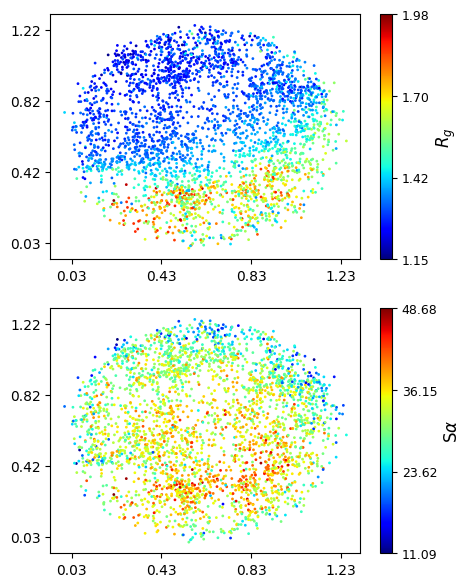

In [29]:
from writhe_tools.plots import fes2d, proj2d, subplots_proj2d,  subplots_fes2d
fig, axes = plt.subplots(2, 1, figsize=(5, 7))
for name, c, ax in zip(r'$R_{g}$,S$\alpha$'.split(','), (rg, Sa), axes.flat):
    proj2d(elvim, c=c, cbar_label=name, ax=ax, dot_size=1)
# subplots_proj2d(rows=1,cols= 2, dscrs=r'$R_{g}$,S$\alpha$'.split(','), c=[rg, Sa],
#             x=elvim, cmap='jet', figsize=(8, 4), font_scale=1.2, sharey=False, cbar_label= r'$R_{g}$,S$alpha$'.split(','))


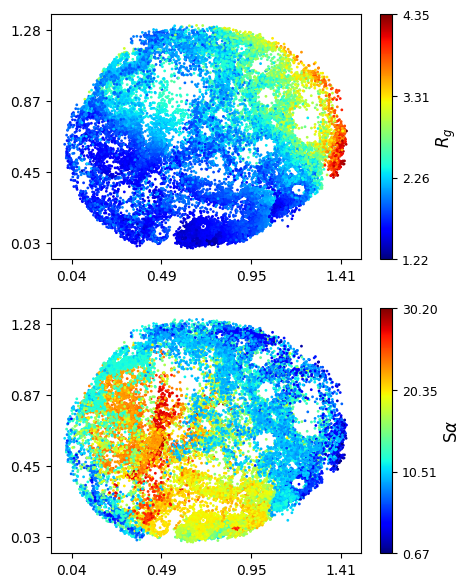

In [30]:
from writhe_tools.plots import fes2d, proj2d, subplots_proj2d,  subplots_fes2d
fig, axes = plt.subplots(2, 1, figsize=(5, 7))
for name, c, ax in zip(r'$R_{g}$,S$\alpha$'.split(','), (rg_MD, Sa_MD), axes.flat):
    proj2d(elvim_MD, c=c, cbar_label=name, ax=ax, dot_size=1)

In [31]:
elvim_dir = '/Users/kaushikborthakur1211/Desktop/Berlin_collab/elvim_data/'
weights_disp = np.loadtxt(elvim_dir+'weights_disp.dat')
weights_disp = weights_disp[::10]
weights_c22 = np.loadtxt(elvim_dir+'weights_c22.dat')
weights_c22 = weights_c22[::10]
weights_c36m = np.loadtxt(elvim_dir+'weights_c36m.dat')
weights_c36m = weights_c36m[::10]

In [32]:
rg_disp = np.loadtxt(elvim_dir+'Rg_disp.dat')
rg_disp = rg_disp[::10]
rg_c22 = np.loadtxt(elvim_dir+'Rg_c22.dat')
rg_c22 = rg_c22[::10]
rg_c36m = np.loadtxt(elvim_dir+'Rg_c36m.dat')
rg_c36m = rg_c36m[::10]

In [33]:
sa_disp = np.loadtxt(elvim_dir+'Sa_disp.dat')
sa_disp = sa_disp[::10]
sa_c22 = np.loadtxt(elvim_dir+'Sa_c22.dat')
sa_c22 = sa_c22[::10]
sa_c36m = np.loadtxt(elvim_dir+'Sa_c36m.dat')
sa_c36m = sa_c36m[::10]


In [34]:
lengths = np.array([3000, len(sa_disp), len(sa_c22), len(sa_c36m)])

In [35]:
sa_cg = np.loadtxt(elvim_dir+'Sa_CG.dat')
rg_cg = np.loadtxt(elvim_dir+'Rg_CG.dat')
weights_cg = np.loadtxt(elvim_dir+'weights_CG.dat')

In [36]:
elvim = np.loadtxt(elvim_dir+'combined.elvim.dat')
elvims = np.array_split(elvim,indices_or_sections = np.cumsum(lengths)[:-1])

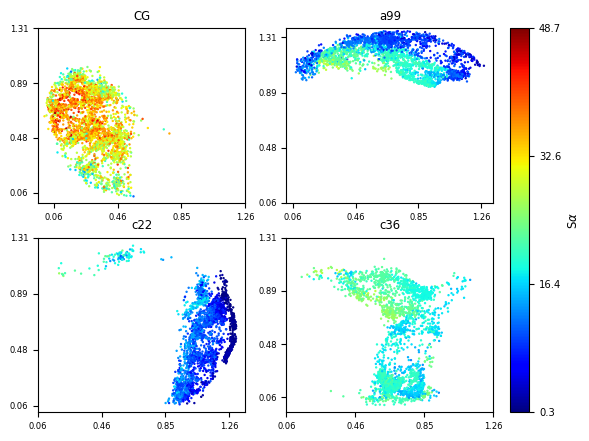

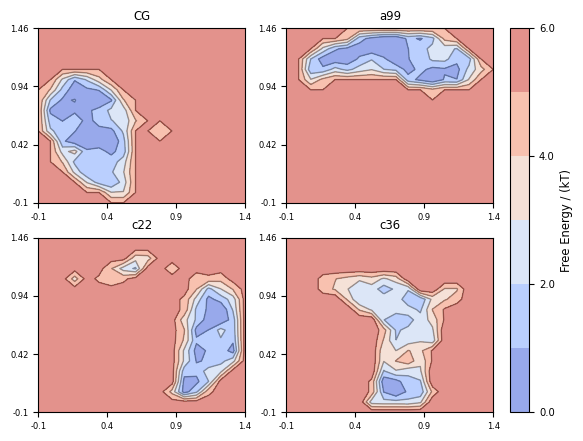

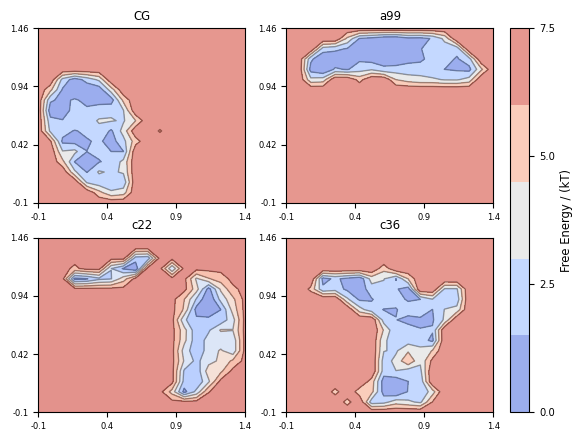

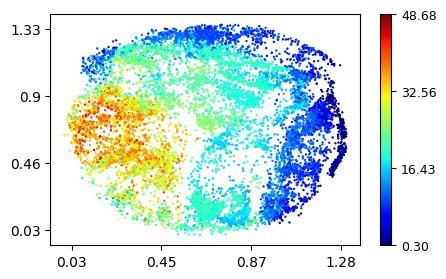

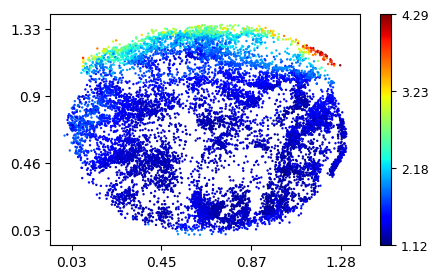

In [37]:
from writhe_tools.plots import subplots_proj2d, proj2d, subplots_fes2d
labels = ['CG', 'a99', 'c22', 'c36']

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .1) for i in elvim.T]

subplots_proj2d(elvims,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6), cbar_label=r'S$\alpha$')
subplots_fes2d(elvims , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,**fes2d_args)
subplots_fes2d(elvims , 2, 2, dscrs=labels, figsize=(6, 6),extent=extent, share_extent=True, weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)
proj2d(elvim, np.concatenate([sa_cg, sa_disp, sa_c22, sa_c36m]))
proj2d(elvim, np.concatenate([rg_cg, rg_disp, rg_c22, rg_c36m]))

In [41]:
top = md.load(pdb).top

In [42]:
from writhe_tools.utils import lsdir, reindex_list
from writhe_tools.md_tools import ResidueDistances
import mdtraj as md
files = reindex_list(lsdir(".", keyword = ['xtc'], exclude=['combined', 'out', 'maker'], match=all), [2, -1, 0, 1])
pdb = './structure.pdb'
distances = [ResidueDistances(index_0=np.arange(71), traj=md.load(file, top=pdb, atom_indices=top.select('name CA'))) for file in files]


/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/utils/sorting.py:79: UserWarning: Not all strings contain a number, returning unsorted input list to avoid throwing an error. If you want to only consider strings that contain a digit, set indexed to True 
  warnings.warn("Not all strings contain a number, returning unsorted input list to avoid throwing an error. "


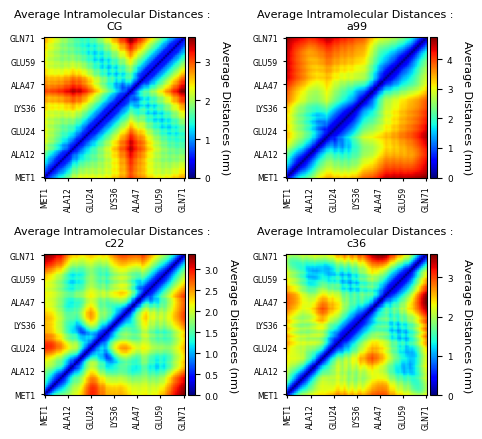

In [44]:
from importlib import reload
import writhe_tools
reload(writhe_tools)
reload(writhe_tools.plots)
from writhe_tools.plots import subplots_fes2d, subplots_proj2d

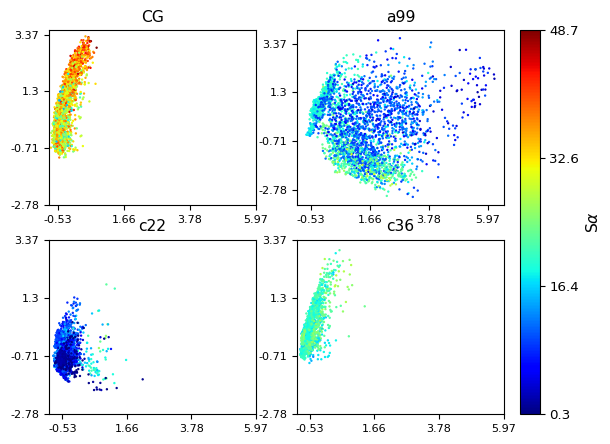

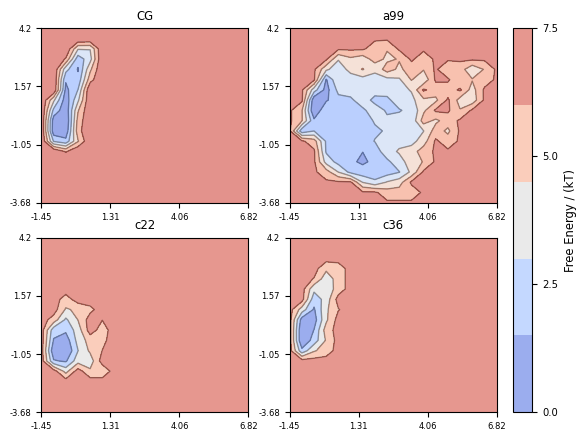

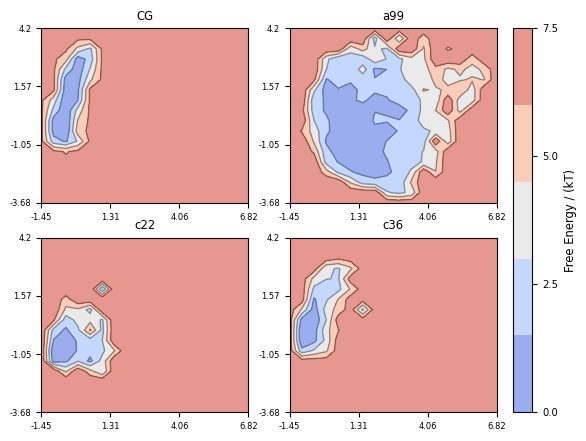

In [80]:
from writhe_tools.stats import pca
lengths = [len(i.distances) for i in distances]
cat = np.concatenate([i.distances for i in distances], axis=0)
mu = cat.mean(0)
proj, s, v = pca(cat, scale_projection=True)

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .6) for i in proj[:, :2].T]

all_projs = [i[:, :2] for i in np.array_split(proj, np.cumsum(lengths)[:-1])]
subplots_proj2d(all_projs,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6), font_scale=0.8, 
                cbar_label=r'S$\alpha$')
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True, **fes2d_args)
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), extent=extent, share_extent=True,
               weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m], **fes2d_args)

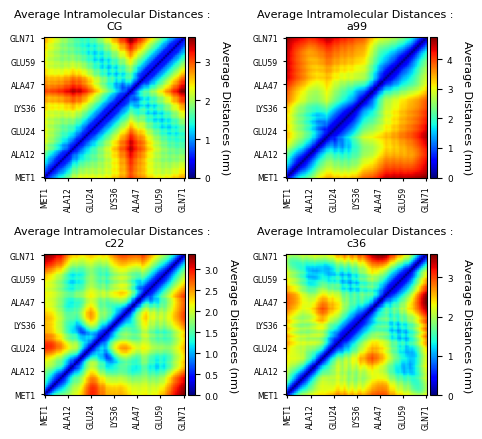

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(5, 4.5))
for ax, obj, label in zip(axes.flat, distances, labels):
    obj.plot(ax=ax, xticks_rotation=90, label_stride=10, dscr=f'\n{label}', font_scale=.8)
    
fig.tight_layout()

In [83]:
from writhe_tools.md_tools import to_distance_matrix

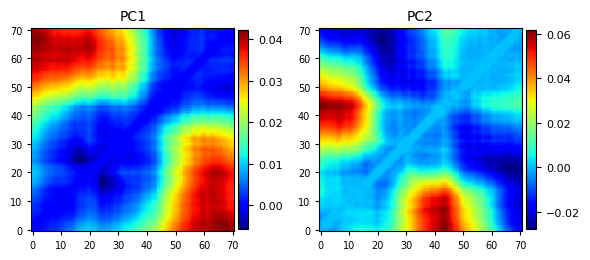

In [94]:
from writhe_tools.writhe import to_writhe_matrix
from writhe_tools.plots import plot_distance_matrix
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
plot_distance_matrix(to_distance_matrix(v.T[0], 71,).squeeze(), label_stride=8, ax=axes[0],
                     cmap='jet', title='PC1')
plot_distance_matrix(to_distance_matrix(v.T[1], 71,).squeeze(), label_stride=8, ax=axes[1],
                     cmap='jet', title='PC2')
fig.tight_layout()

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


<Axes: title={'center': 'Weighted Similarties'}>

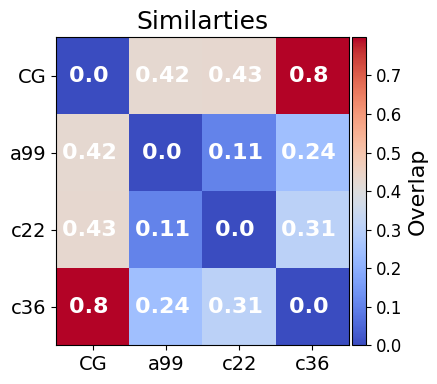

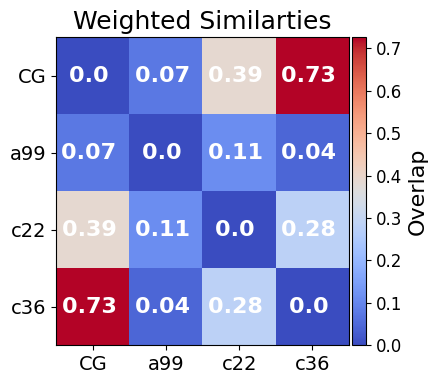

In [100]:
from writhe_tools.stats import DensityComparator

comp = DensityComparator(all_projs, weights=[weights_cg, weights_disp, weights_c22, weights_c36m])
comp.estimate_kde()
comp.estimate_hist(bins=20)
comp.estimate_hist(bins=20, weight=True)
#comp.compare('kdes')
#comp.compare('hists')

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists')
mat += mat.T
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )

mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists', weight=True)
mat += mat.T
annotated_matrix_plot(mat, tick_labels=labels, title='Weighted Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.4, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )


In [79]:
from writhe_tools.stats import pca
from writhe_tools.writhe import Writhe

writhes = [Writhe(md.load(file, top=pdb, atom_indices=top.select('name CA')).xyz).compute_writhe(1, multi_proc=False)['writhe_features'] for file in files]

/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/writhe.py:260: UserWarning: You are not using any multiprocessing or GPUs! Multiprocessing on CPU is managed by ray or numba.ray handles big jobs best and is fastest!..... using torch broadcast calculation (returns numpy)
  warnings.warn("You are not using any multiprocessing or GPUs! "


/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/writhe.py:260: UserWarning: You are not using any multiprocessing or GPUs! Multiprocessing on CPU is managed by ray or numba.ray handles big jobs best and is fastest!..... using torch broadcast calculation (returns numpy)
  warnings.warn("You are not using any multiprocessing or GPUs! "
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/writhe.py:260: UserWarning: You are not using any multiprocessing or GPUs! Multiprocessing on CPU is managed by ray or numba.ray handles big jobs best and is fastest!..... using torch broadcast calculation (returns numpy)
  warnings.warn("You are not using any multiprocessing or GPUs! "
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/writhe.py:260: UserWarning: You are not using any multiprocessing or GPUs! Multiprocessing on CPU is managed by ray or numba.ray handles

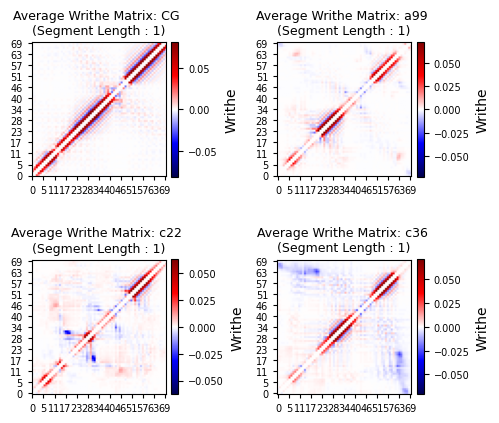

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(5, 4.5))

for ax, wr, label in zip(axes.flat,
                         [Writhe(md.load(file, top=pdb, atom_indices=top.select('name CA')).xyz) for file in files],
                         labels):
    wr.compute_writhe(1, multi_proc=False)
    wr.plot_writhe_matrix(ax=ax, dscr=label)
    
fig.tight_layout()

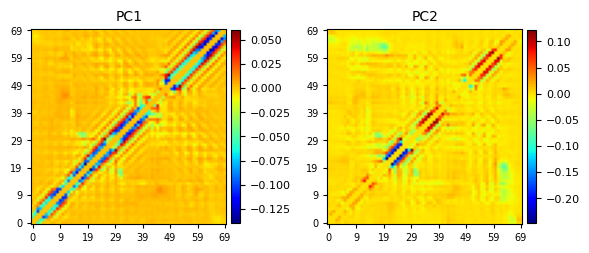

In [78]:
from writhe_tools.writhe import to_writhe_matrix
from writhe_tools.plots import plot_distance_matrix
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
plot_distance_matrix(to_writhe_matrix(v.T[0].reshape(1, -1), 71, 1).squeeze(), label_stride=8, ax=axes[0],
                     cmap='jet', title='PC1')
plot_distance_matrix(to_writhe_matrix(v.T[1].reshape(1, -1), 71, 1).squeeze(), label_stride=8, ax=axes[1],
                     cmap='jet', title='PC2')
fig.tight_layout()

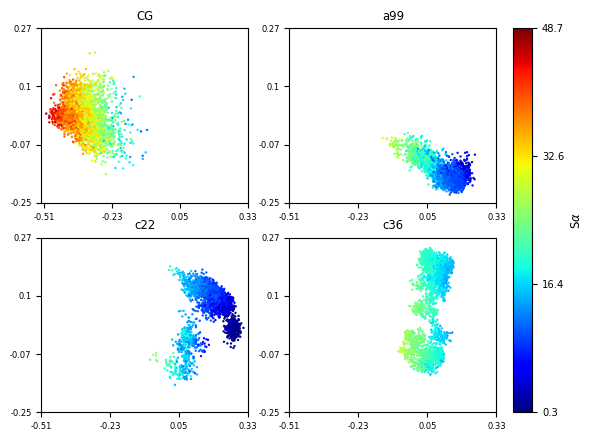

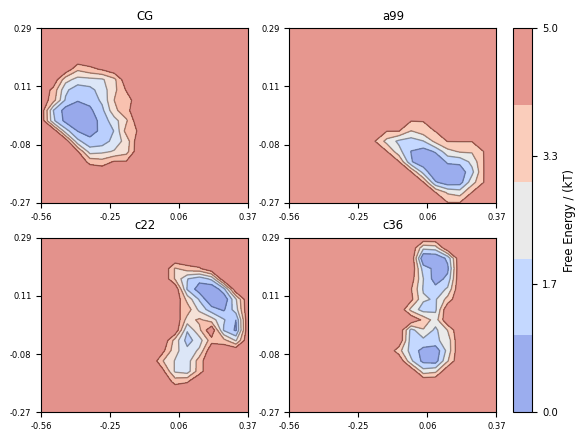

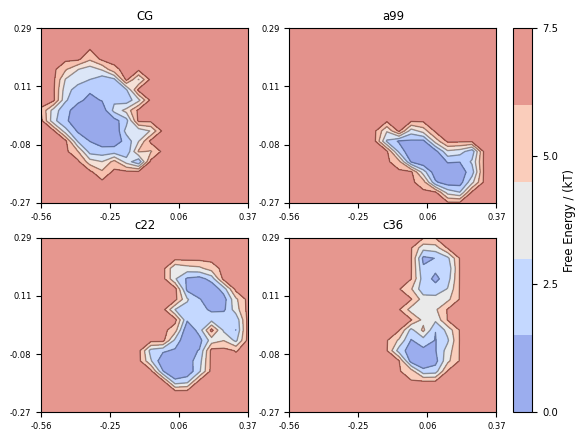

In [74]:
cat = np.concatenate(writhes, axis=0)
#mu = cat.mean(0)
proj, s, v = pca(cat)
all_projs = [i[:, :2] for i in np.array_split(proj, np.cumsum(lengths)[:-1])]

from writhe_tools.plots import get_extrema
extent = [get_extrema(i, .05) for i in proj[:, :2].T]

subplots_proj2d(all_projs,[sa_cg, sa_disp, sa_c22, sa_c36m] , 2, 2, dscrs=labels, figsize=(6, 6),
                extent=extent, cbar_label=r'S$\alpha$')
# subplots_proj2d(all_projs,[rg_cg, rg_disp, rg_c22, rg_c36m] , 2, 2, dscrs=labels, figsize=(6, 6),
#             extent=extent, cbar_label=r'Rg', vmax=2)

subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), share_extent=True, extent=extent,  **fes2d_args)
subplots_fes2d(all_projs , 2, 2, dscrs=labels, figsize=(6, 6), share_extent=True,
               weights_list=[weights_cg, weights_disp, weights_c22, weights_c36m],extent=extent, **fes2d_args)

In [48]:
reload(writhe_tools)
reload(writhe_tools.plots)
from writhe_tools.plots import annotated_matrix_plot


/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1003: UserWarning: Bins to use in densitiy estimators has already been set to 80. Changing to 20. Consider recomputing all densities
  warnings.warn(
/Users/kaushikborthakur1211/opt/anaconda3/envs/writhe/lib/python3.10/site-packages/writhe_tools/stats.py:1019: UserWarning: Using densities defined by histograms in the computation of a comparison metric can cause counter intuitive results because empty bins are masked out to prevent nans
  warnings.warn((


<Axes: title={'center': 'Similarties'}>

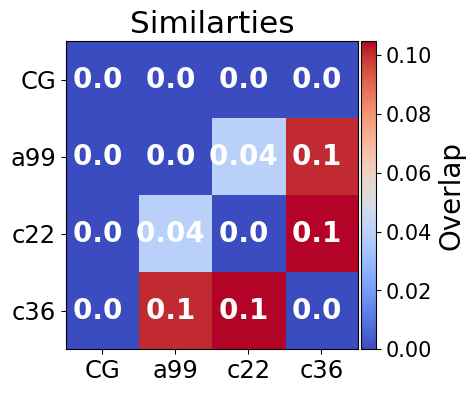

In [73]:
from writhe_tools.stats import DensityComparator

comp = DensityComparator(all_projs)
comp.estimate_kde()
comp.estimate_hist(bins=20)
#comp.compare('kdes')
comp.compare('hists')
mat = np.zeros((4, 4))
i, j = np.triu_indices(4, 1)
mat[i, j] = comp.compare('hists')
mat += mat.T
annotated_matrix_plot(mat, tick_labels=labels, title='Similarties',
                      cbar_label='Overlap', figsize=(4, 4),
                      font_scale=.5, cmap='coolwarm',
                      xlabel='', ylabel='',
                      )


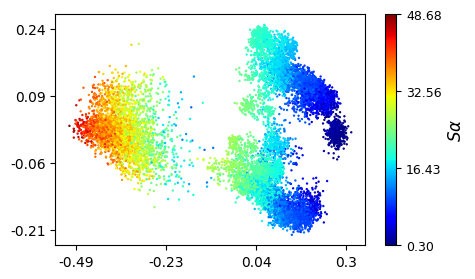

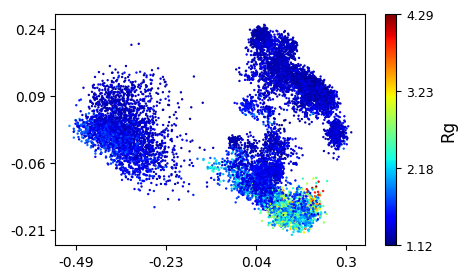

In [51]:
proj2d(proj[:, :2], np.concatenate([sa_cg, sa_disp, sa_c22, sa_c36m]), cbar_label=r'$S\alpha$')
proj2d(proj[: ,:2], np.concatenate([rg_cg, rg_disp, rg_c22, rg_c36m]), cbar_label=r'Rg')

In [ ]:
from writhe_tools.stats import DensityComparator

In [ ]:
DensityComparator()

'/Users/kaushikborthakur1211/Desktop/Berlin_collab'